Duración: 4.87 s
Configuración 1: FFT=64 | Traslape=0%
  FFT: 64
  Ventana: 64 muestras
  Traslape: 0%
  Shape: (1, 33, 1217)



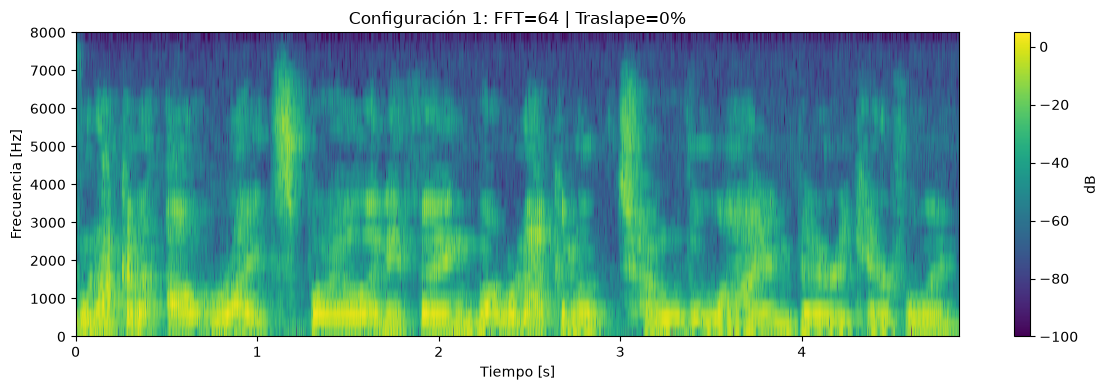

Configuración 2: FFT=64 | Traslape=25%
  FFT: 64
  Ventana: 64 muestras
  Traslape: 25%
  Shape: (1, 33, 1623)



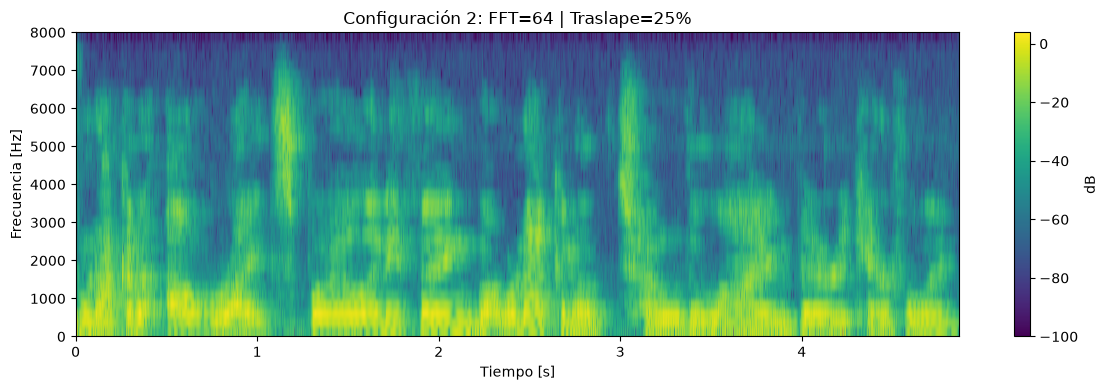

Configuración 3: FFT=64 | Traslape=50%
  FFT: 64
  Ventana: 64 muestras
  Traslape: 50%
  Shape: (1, 33, 2434)



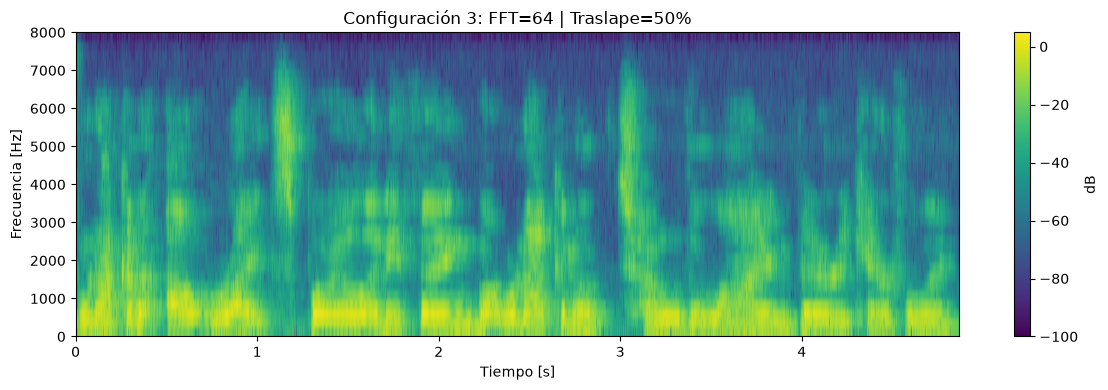

Configuración 4: FFT=128 | Traslape=0%
  FFT: 128
  Ventana: 128 muestras
  Traslape: 0%
  Shape: (1, 65, 609)



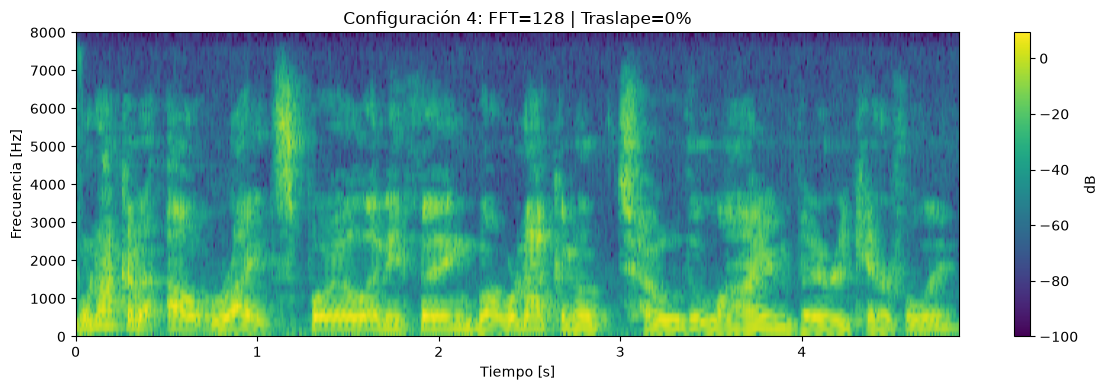

Configuración 5: FFT=128 | Traslape=25%
  FFT: 128
  Ventana: 128 muestras
  Traslape: 25%
  Shape: (1, 65, 812)



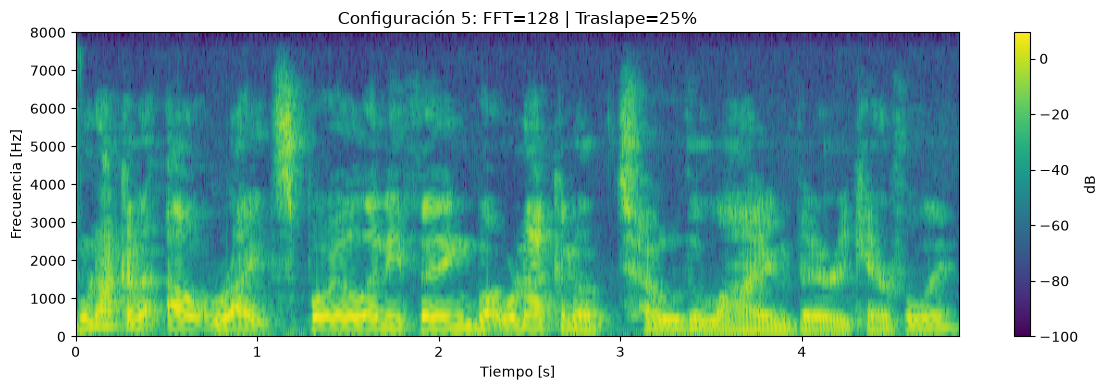

Configuración 6: FFT=128 | Traslape=50%
  FFT: 128
  Ventana: 128 muestras
  Traslape: 50%
  Shape: (1, 65, 1217)



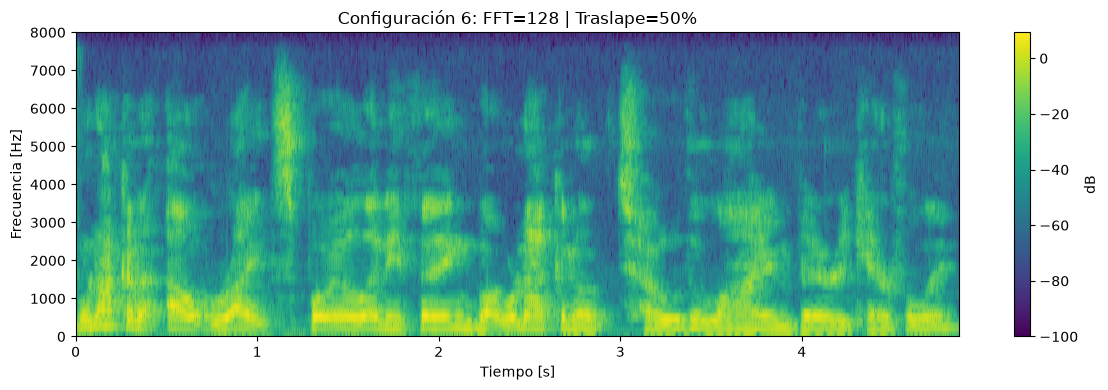

Configuración 7: FFT=256 | Traslape=0%
  FFT: 256
  Ventana: 256 muestras
  Traslape: 0%
  Shape: (1, 129, 305)



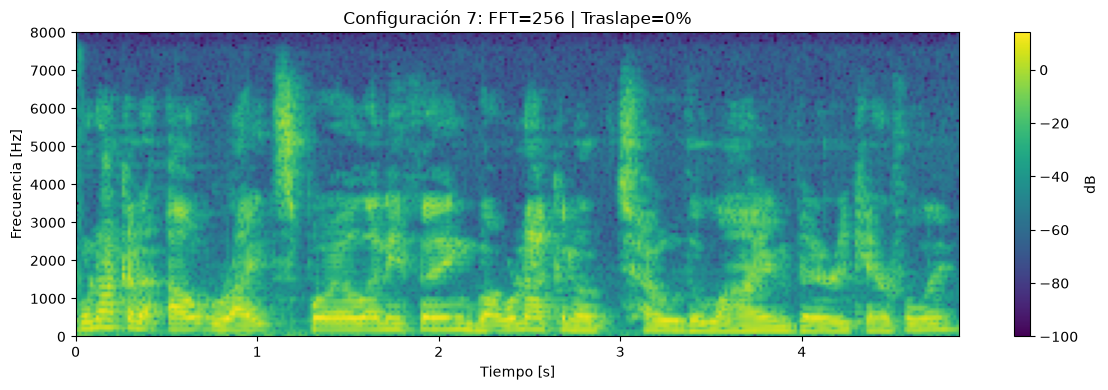

Configuración 8: FFT=256 | Traslape=25%
  FFT: 256
  Ventana: 256 muestras
  Traslape: 25%
  Shape: (1, 129, 406)



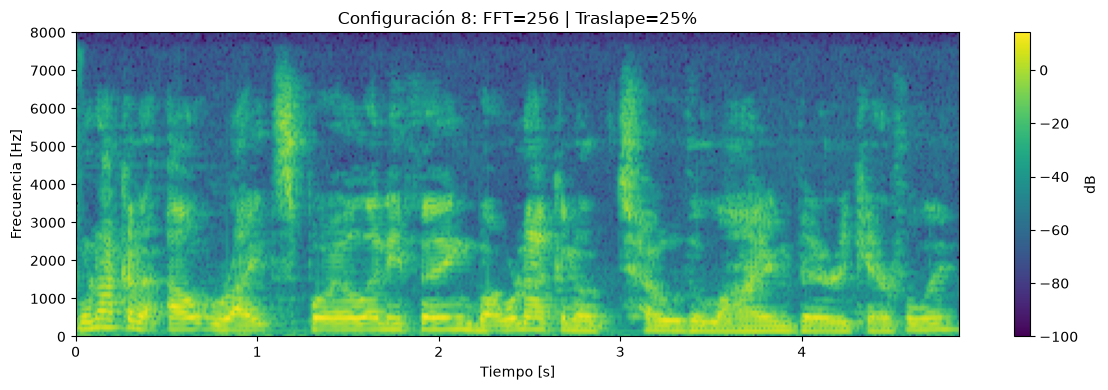

Configuración 9: FFT=256 | Traslape=50%
  FFT: 256
  Ventana: 256 muestras
  Traslape: 50%
  Shape: (1, 129, 609)



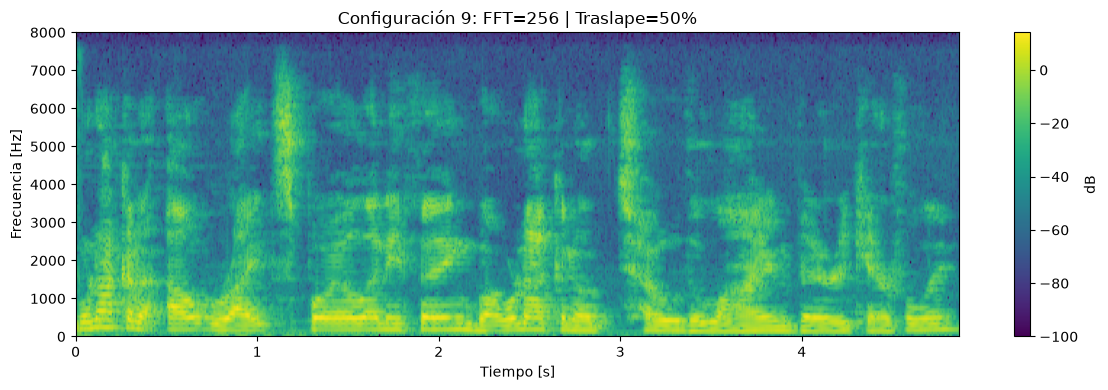

Configuración 10: FFT=512 | Traslape=0%
  FFT: 512
  Ventana: 512 muestras
  Traslape: 0%
  Shape: (1, 257, 153)



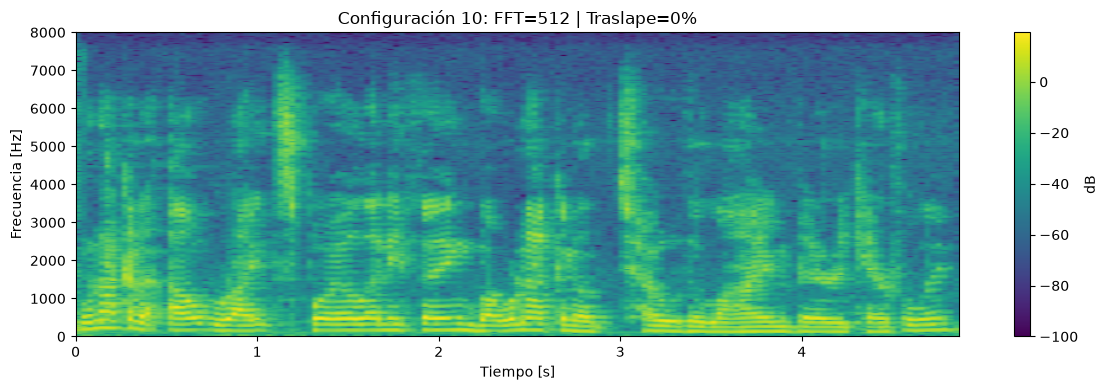

Configuración 11: FFT=512 | Traslape=25%
  FFT: 512
  Ventana: 512 muestras
  Traslape: 25%
  Shape: (1, 257, 203)



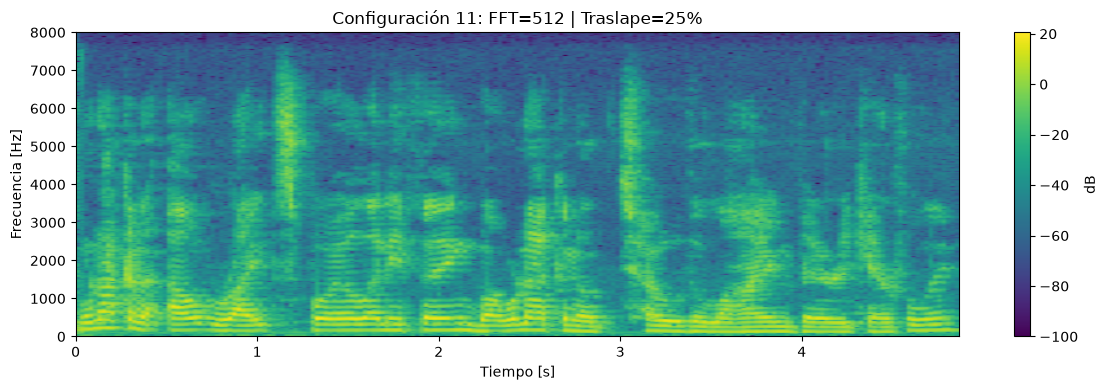

Configuración 12: FFT=512 | Traslape=50%
  FFT: 512
  Ventana: 512 muestras
  Traslape: 50%
  Shape: (1, 257, 305)



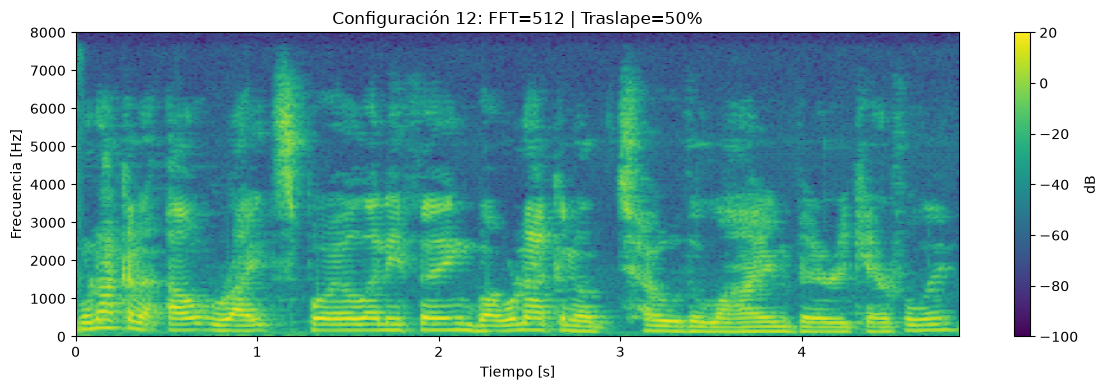

In [1]:
import torch
import torchaudio
import matplotlib.pyplot as plt

audio_path = "Emociones\\Podcast\\train\\0.wav"

waveform, sample_rate = torchaudio.load(audio_path)
waveform = waveform[0]

print(f"Duración: {len(waveform) / sample_rate:.2f} s")


def plot_spectrogram(
    waveform,
    sample_rate,
    n_fft,
    overlap,
    title=""
):

    win_length = n_fft

    hop_length = int(n_fft * (1 - overlap))

    transform = torchaudio.transforms.Spectrogram(
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        power=2
    )

    spectrogram = transform(waveform.unsqueeze(0))

    db_transform = torchaudio.transforms.AmplitudeToDB()
    spectrogram_db = db_transform(spectrogram)

    print(
        f"{title}\n"
        f"  FFT: {n_fft}\n"
        f"  Ventana: {win_length} muestras\n"
        f"  Traslape: {overlap * 100:.0f}%\n"
        f"  Shape: {tuple(spectrogram.shape)}\n"
    )

    plt.figure(figsize=(12, 4))

    plt.imshow(
        spectrogram_db[0].numpy(),
        aspect="auto",
        origin="lower",
        extent=[
            0,
            len(waveform) / sample_rate,
            0,
            sample_rate / 2
        ]
    )

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.title(title)
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()



n_fft_values = [64, 128, 256, 512]

overlap_values = [0, 0.25, 0.50]



configuracion = 1

for n_fft in n_fft_values:

    for overlap in overlap_values:

        plot_spectrogram(
            waveform,
            sample_rate,
            n_fft=n_fft,
            overlap=overlap,
            title=(
                f"Configuración {configuracion}: "
                f"FFT={n_fft} | "
                f"Traslape={overlap * 100:.0f}%"
            )
        )

        configuracion += 1